## Mounting the Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 1: Data Preprocessing

In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_path = "/content/drive/MyDrive/multilabel_modified/"
csv_path = data_path + "multilabel_classification.csv"
images_dir = data_path + "images/"

In [4]:
df = pd.read_csv(csv_path)
df.columns = ["filename", "classes"]
df.head()

,filename,classes
0,Image_Name,Classes
1,image0.jpg,
2,image1.jpg,bus person
3,image2.jpg,sitar
4,image3.jpg,flutes


In [5]:
all_labels = ["motorcycle", "truck", "train", "bus", "cycle",
              "sitar", "ektara", "flutes", "tabla", "harmonium"]

def encode_labels(label_str):
    labels = str(label_str).split() if pd.notna(label_str) else []
    return [1 if l in labels else 0 for l in all_labels]

df["label_vector"] = df["classes"].apply(encode_labels)

In [6]:
X = [os.path.join(images_dir, fname) for fname in df["filename"]]
y = np.array(df["label_vector"].tolist())

# Filter out missing files
valid_X, valid_y = [], []
for path, label in zip(X, y):
    if os.path.exists(path):
        valid_X.append(path)
        valid_y.append(label)

X = valid_X
y = np.array(valid_y)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

## Task 2: Apply ANN

In [8]:
IMG_SIZE = (64, 64)

def process_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)

In [9]:
model = Sequential([
    Flatten(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),   # Flatten images
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(len(all_labels), activation="sigmoid")   # sigmoid for multilabel
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 603s 4s/step - accuracy: 0.2552 - loss: 0.3954 - val_accuracy: 0.3512 - val_loss: 0.2733
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 34s 224ms/step - accuracy: 0.3639 - loss: 0.2611 - val_accuracy: 0.3014 - val_loss: 0.2639
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 38s 207ms/step - accuracy: 0.4022 - loss: 0.2332 - val_accuracy: 0.3483 - val_loss: 0.2588
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 200ms/step - accuracy: 0.4322 - loss: 0.2155 - val_accuracy: 0.3627 - val_loss: 0.2507
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 35s 231ms/step - accuracy: 0.4662 - loss: 0.2007 - val_accuracy: 0.3627 - val_loss: 0.2402
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 35s 192ms/step - accuracy: 0.4880 - loss: 0.1876 - val_accuracy: 0.3474 - val_loss: 0.2551
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.4994 - loss: 0.1808 - val_accuracy: 0.3742 - val_loss: 0.2335
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 42s 198ms/step - accuracy: 0.5227 - loss: 0.1

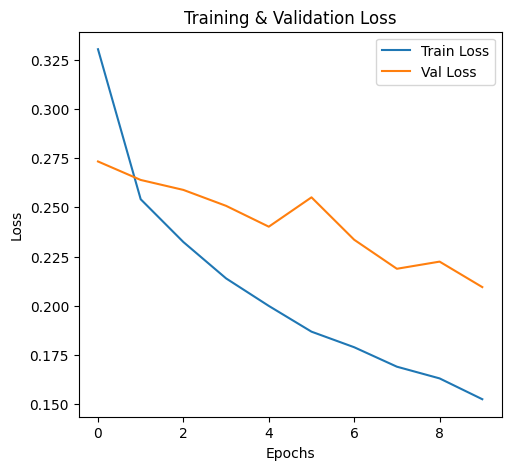

In [12]:
# Loss Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

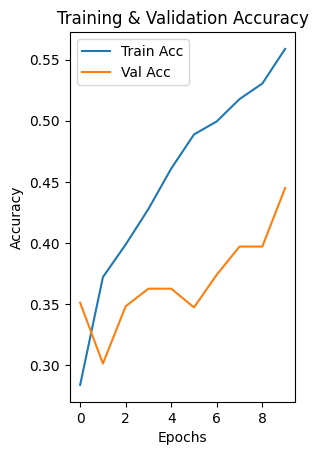

In [13]:
# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

## Task 3: Apply CNN

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [18]:
model_cnn = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(len(all_labels), activation="sigmoid")
])

In [19]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 47s 300ms/step - accuracy: 0.1832 - loss: 0.3317 - val_accuracy: 0.3100 - val_loss: 0.2380
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 44s 287ms/step - accuracy: 0.3266 - loss: 0.2340 - val_accuracy: 0.4507 - val_loss: 0.1932
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 53s 346ms/step - accuracy: 0.4149 - loss: 0.2001 - val_accuracy: 0.4909 - val_loss: 0.1668
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 74s 296ms/step - accuracy: 0.4940 - loss: 0.1756 - val_accuracy: 0.5435 - val_loss: 0.1509
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 86s 321ms/step - accuracy: 0.5257 - loss: 0.1592 - val_accuracy: 0.5483 - val_loss: 0.1401
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 49s 321ms/step - accuracy: 0.5459 - loss: 0.1492 - val_accuracy: 0.6201 - val_loss: 0.1317
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 77s 287ms/step - accuracy: 0.5817 - loss: 0.1331 - val_accuracy: 0.5990 - val_loss: 0.1242
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 49s 322ms/step - accuracy: 0.5917 - loss: 0

Text(0.5, 1.0, 'Loss')

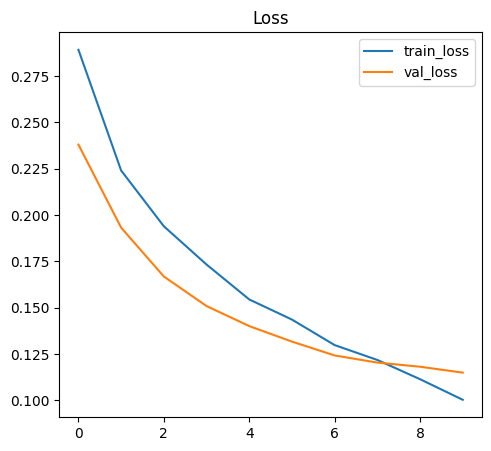

In [22]:
# Loss Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['loss'], label='train_loss')
plt.plot(history_cnn.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")

Text(0.5, 1.0, 'Accuracy')

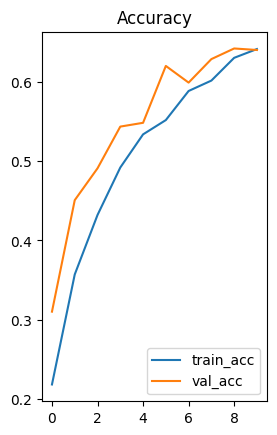

In [23]:
# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history_cnn.history['accuracy'], label='train_acc')
plt.plot(history_cnn.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")

In [24]:
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = model_cnn.predict(imgs)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype("int"))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(
    y_true, y_pred, target_names=all_labels, zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━

## Task 4: Apply Transfer Learning

In [25]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [26]:
IMG_SIZE = (64,64)
BATCH_SIZE = 32

def preprocess_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE) / 255.0
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [27]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

/tmp/ipython-input-2672418720.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(len(all_labels), activation="sigmoid")(x)

In [29]:
model_tl = Model(inputs=base_model.input, outputs=outputs)

In [30]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [31]:
model_tl.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 49s 277ms/step - accuracy: 0.1742 - loss: 0.5462 - val_accuracy: 0.5301 - val_loss: 0.1884
Epoch 2/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 35s 228ms/step - accuracy: 0.4583 - loss: 0.2198 - val_accuracy: 0.6048 - val_loss: 0.1512
Epoch 3/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - accuracy: 0.5394 - loss: 0.1782 - val_accuracy: 0.6115 - val_loss: 0.1354
Epoch 4/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 40s 261ms/step - accuracy: 0.6066 - loss: 0.1481 - val_accuracy: 0.6421 - val_loss: 0.1255
Epoch 5/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.6087 - loss: 0.1386 - val_accuracy: 0.6536 - val_loss: 0.1199


In [33]:
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = model_tl.predict(test_ds)
y_pred_bin = (y_pred > 0.5).astype(int)

print(classification_report(y_true, y_pred_bin, target_names=all_labels))

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step
              precision    recall  f1-score   support

  motorcycle       0.83      0.63      0.72       158
       truck       0.63      0.55      0.59       125
       train       0.00      0.00      0.00         0
         bus       0.82      0.38      0.52       108
       cycle       0.91      0.83      0.87       241
       sitar       0.92      0.50      0.65        44
      ektara       1.00      0.20      0.33        30
      flutes       0.76      0.39      0.52        33
       tabla       0.94      0.64      0.76       119
   harmonium       0.87      0.38      0.53        34

   micro avg       0.84      0.60      0.70       892
   macro avg       0.77      0.45      0.55       892
weighted avg       0.85      0.60      0.69       892
 samples avg       0.50      0.50      0.50       892



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

## Task 5: Model Comparison &amp; ROC Curves

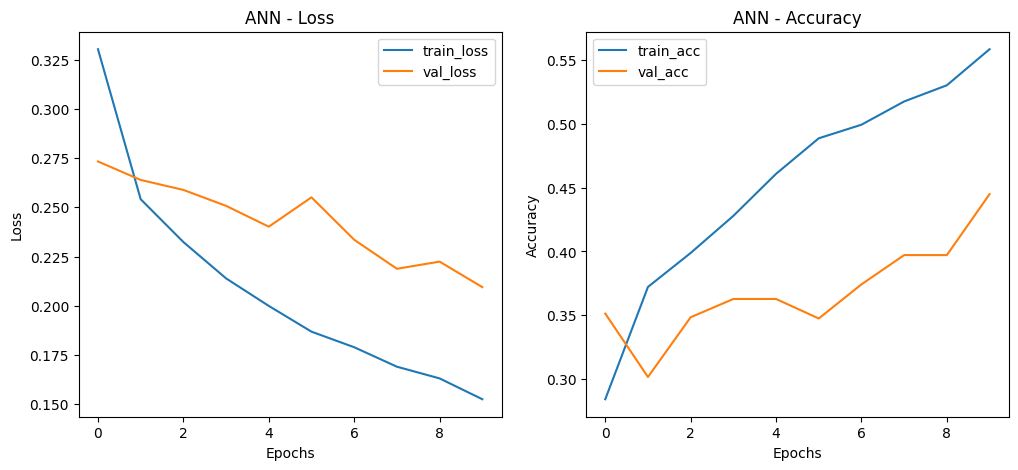

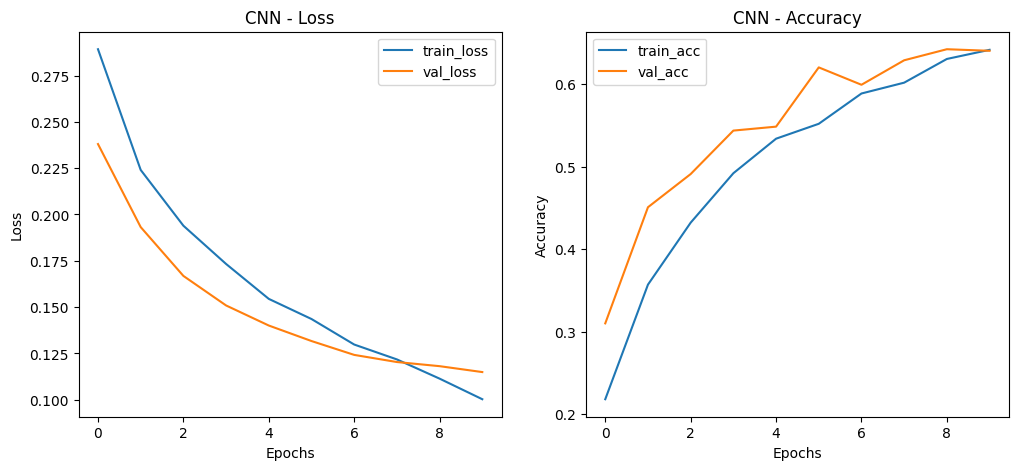

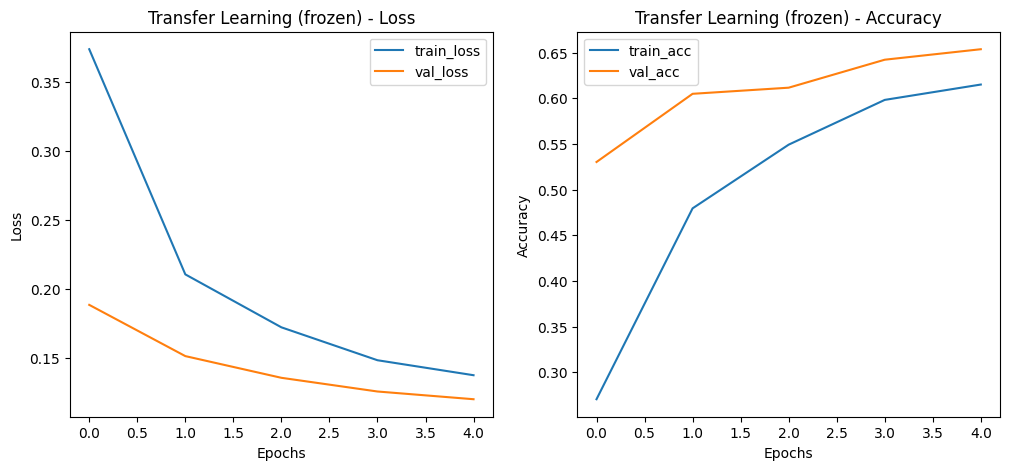

In [34]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label="train_loss")
    plt.plot(history.history['val_loss'], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label="train_acc")
    plt.plot(history.history['val_accuracy'], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

plot_history(history, "ANN")
plot_history(history_cnn, "CNN")
plot_history(history_tl, "Transfer Learning (frozen)")

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


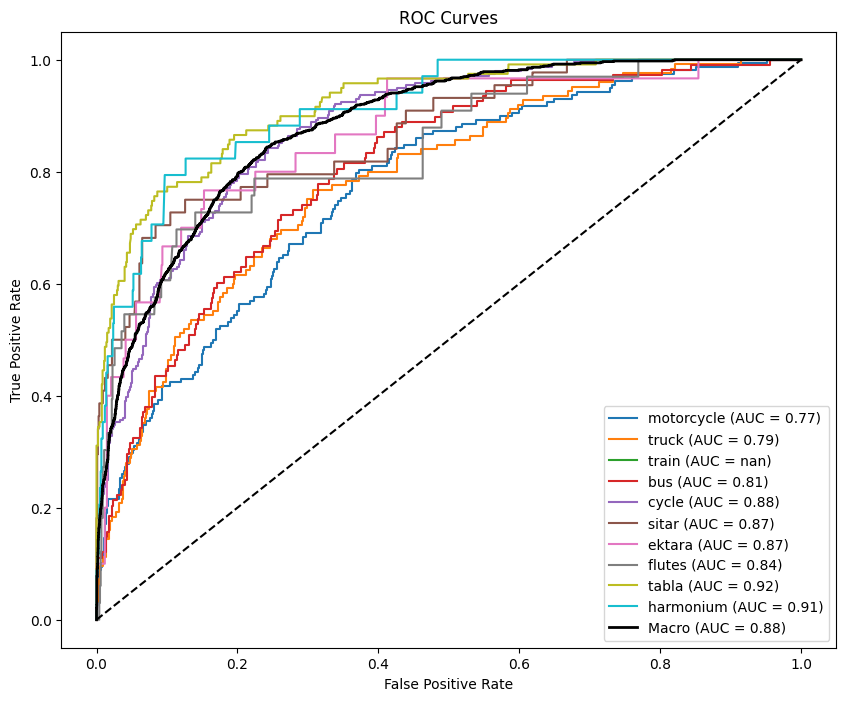

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


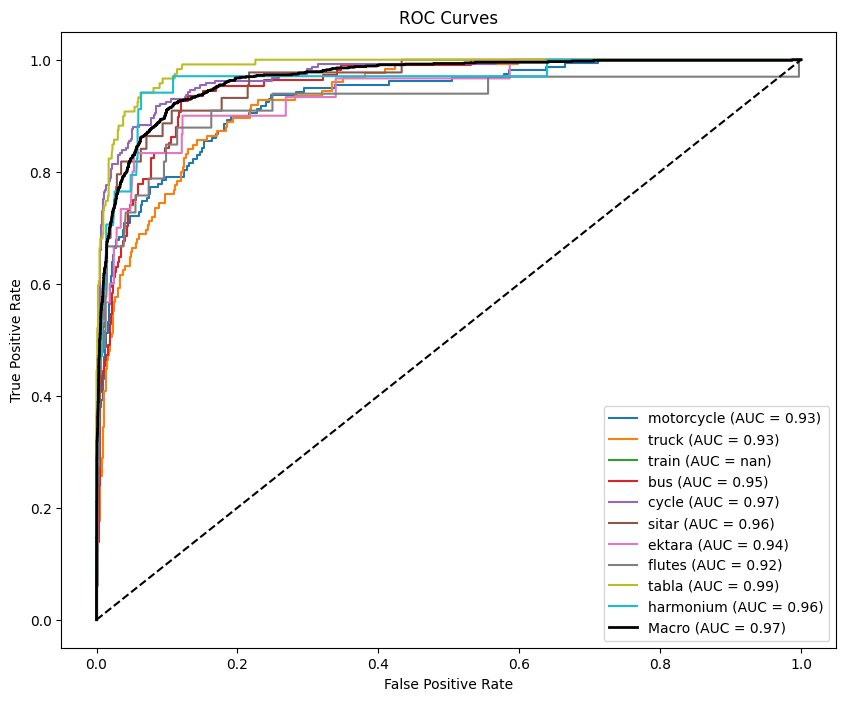

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


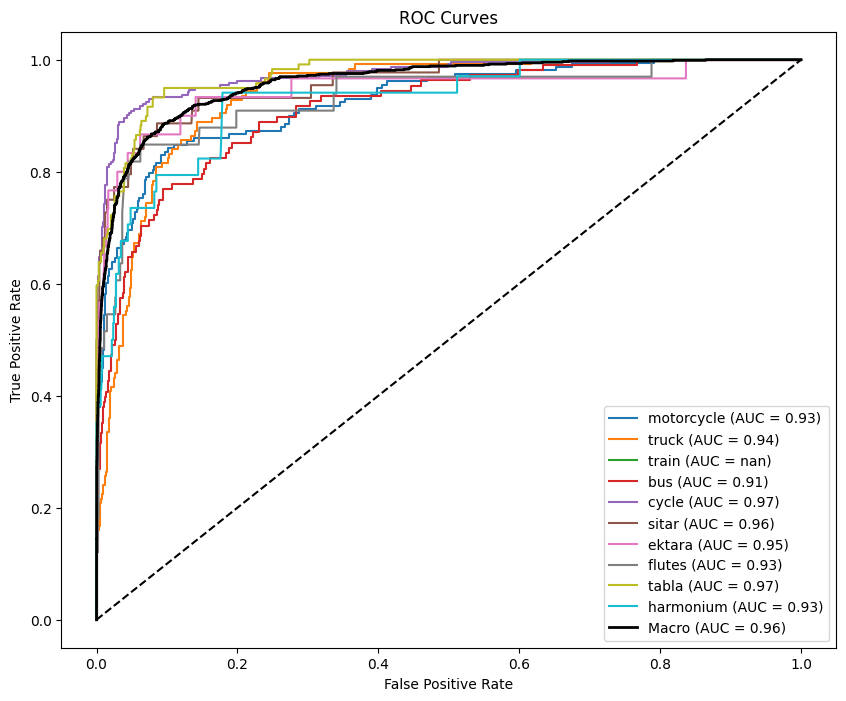

In [35]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc(y_true, y_pred, labels):
    plt.figure(figsize=(10,8))

    # Per-label ROC
    for i, label in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

    # Macro-average ROC
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_pred.ravel())
    plt.plot(fpr, tpr, color="black", lw=2, label=f"Macro (AUC = {auc(fpr, tpr):.2f})")

    plt.plot([0,1],[0,1],"k--")
    plt.title("ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Example with Transfer Learning preds:
y_true = np.concatenate([y for x,y in test_ds], axis=0)
y_pred_ann  = model.predict(test_ds)       # ANN
y_pred_cnn  = model_cnn.predict(test_ds)   # CNN
y_pred_tl   = model_tl.predict(test_ds)    # TL

plot_roc(y_true, y_pred_ann, all_labels)
plot_roc(y_true, y_pred_cnn, all_labels)
plot_roc(y_true, y_pred_tl, all_labels)


In [36]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(y_true, y_pred, labels, name):
    y_pred_bin = (y_pred > 0.5).astype(int)

    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred_bin, target_names=labels))
    auc_score = roc_auc_score(y_true, y_pred, average="macro")
    print(f"Macro AUC: {auc_score:.4f}\n")

evaluate_model(y_true, y_pred_ann, all_labels, "ANN")
evaluate_model(y_true, y_pred_cnn, all_labels, "CNN")
evaluate_model(y_true, y_pred_tl, all_labels, "Transfer Learning")

=== ANN ===
              precision    recall  f1-score   support

  motorcycle       0.57      0.23      0.33       158
       truck       0.41      0.31      0.35       125
       train       0.00      0.00      0.00         0
         bus       1.00      0.06      0.11       108
       cycle       0.69      0.51      0.58       241
       sitar       0.81      0.39      0.52        44
      ektara       0.25      0.10      0.14        30
      flutes       0.40      0.18      0.25        33
       tabla       0.57      0.71      0.64       119
   harmonium       0.35      0.56      0.43        34

   micro avg       0.56      0.37      0.45       892
   macro avg       0.51      0.30      0.34       892
weighted avg       0.62      0.37      0.42       892
 samples avg       0.29      0.29      0.28       892

Macro AUC: nan

=== CNN ===
              precision    recall  f1-score   support

  motorcycle       0.84      0.59      0.70       158
       truck       0.69      0.62     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Transfer Learning (MobileNetV2 / ResNet) is the best because it balances accuracy and efficiency.

## Task 6: Model Export

In [37]:
best_model_path = "/content/drive/MyDrive/best_model.h5"
model_tl.save(best_model_path)
print(f"Model saved at {best_model_path}")

Model saved at /content/drive/MyDrive/best_model.h5


In [38]:
from tensorflow.keras.models import load_model
best_model = load_model(best_model_path)
print("Model loaded successfully!")

Model loaded successfully!


In [41]:
from tensorflow.keras.preprocessing import image

def predict_image(model, img_path, labels, img_size=(64,64)):
    # Load & preprocess
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size) / 255.0
    img = tf.expand_dims(img, axis=0)   # add batch dimension

    # Predict
    preds = model.predict(img)[0]
    results = {label: float(p) for label, p in zip(labels, preds)}

    # Print predictions
    print("Predictions:")
    for label, prob in results.items():
        if prob > 0.3:
            print(f"✅ {label}: {prob:.2f}")
        else:
            print(f"❌ {label}: {prob:.2f}")

    return results

# Example usage (pick an image from your dataset or upload new one)
test_image_path = "/content/drive/MyDrive/multilabel_modified/images/image123.jpg"
predict_image(best_model, test_image_path, all_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predictions:
✅ motorcycle: 0.34
❌ truck: 0.01
❌ train: 0.00
❌ bus: 0.01
❌ cycle: 0.07
❌ sitar: 0.01
❌ ektara: 0.01
❌ flutes: 0.01
✅ tabla: 0.47
❌ harmonium: 0.00


{'motorcycle': 0.342180460691452,
 'truck': 0.010313164442777634,
 'train': 0.0008759842021390796,
 'bus': 0.010044470429420471,
 'cycle': 0.07065155357122421,
 'sitar': 0.006138624623417854,
 'ektara': 0.008169978857040405,
 'flutes': 0.005870450288057327,
 'tabla': 0.46897056698799133,
 'harmonium': 0.0018391894409433007}